# Import

In [10]:
import cv2
import warnings
import requests
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# warngin 무시
warnings.filterwarnings(action = 'ignore')

In [3]:
# Directory root
root = '/Users/toad/Documents/ToyProject/car_detection'

# 시각화 함수

In [29]:
def postprocess_image(image, predictions):
    # RGB 변환 되지 않은 이미지를 받아야 함
    # 원본 이미지 복사
    draw_img = image.copy()

    # 클래스 이름 (필요시 수정)
    class_names = ["car"]

    # api 반환 값 분리
    bbox_cnt, coords, infer_time = predictions.values()
    for det in coords:
        # 좌표 가져오기
        x1, y1, x2, y2, score, cls_id = det

        # 박스 그리기
        cv2.rectangle(draw_img, (x1, y1), (x2, y2), (255, 0, 0), 2) # BGR기준

        # 클래스 & 점수 표시
        label = f"{class_names[cls_id]} {score:.2f}"
        cv2.putText(draw_img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
    text = f'Inference Time : {infer_time:0.4}ms'
    cv2.putText(draw_img, text, (10,20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # BGR → RGB 변환
    draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
    return draw_img

# Requests 함수

In [38]:
def detection_request(url, image, conf):
    response = requests.post(url, files=image, data=conf)
    return response.status_code, response.json()

# API Request Test

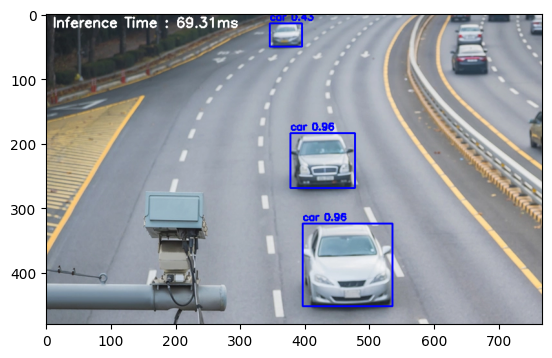

In [41]:
# api 주소
url = 'http://127.0.0.1:8000/detect'

# 보낼 이미지 주소
image_path = f'{root}/test.png'

# 이미지 전송
conf = 0.4
with open(image_path, 'rb') as f: # 파일을 binary로 읽기
    files = {'file' : (image_path, f, 'image/png')}
    data = {'confidence' : conf}
    response_code, reponse_json = detection_request(url, files, data)


# 이미지에 좌표 그리기
image = cv2.imread(image_path)
post_image = postprocess_image(image, reponse_json)
plt.imshow(post_image)